# V768 - Measuring Vision with Psychophysics

## Lab 4 - Contrast Sensitivity Functions

In Lab 3, you learned that a **psychometric function** models the relationship between a given stimulus feature (e.g., contrast) and a participant's forced-choice responses and that psychometric functions are ***inferential models***, meaning that they allow you to infer certain things about the relationship that they model. But what you can infer once you've fit a psychometric function to data? And how does this work across multiple experimental conditions?

In this lab, you'll learn about inferring ***threshold*** and ***sensitivity*** from psychometric functions and about how those numbers allow you to analyze performance when two stimulus features vary. You'll use that knowledge to plot your **contrast sensitivity function** (aka modulation transfer function).

### Learning Outcomes

(i.e., what you will be able to do at the end of this lab)

1. Describe how threshold and sensitivity are measured from a psychometric curve.

2. Explain how forced-choice responses can be analyzed when an experiment involves varying more than one stimulus feature.

3. Describe what a contrast sensitivity function is and how to measure one.

### Questions

1. Include and write a caption for the figure in Part A, Step 3 (altering contrast sensitivity).

2. For the Part A, Step 3 figure, explain the differences between the three curves. What caused them to be different from one another? What impact did that have on the contrast perception represented by each curve?

3. Include and write a caption for the figure in Part C, Step 4 (data and fitted curves).

4. Include and write a caption for the figure in Part C, Step 5 (threshold and sensitivity).

5. What do threshold and sensitivity values tell you about an observer's sensation/perception?

6. If you were presenting results from your own forced choice experiment (in a poster, talk, paper, etc.), do you think you would prefer presenting thresholds or sensitivities? Explain why, discussing pros and cons of both options.

## Part A. Simulate Psychometric Functions

<u>Psychometric functions are a fundamental part of psychophysics research.</u> Lab 3 introduced you to psychometric functions and gave you some experience with fitting a psychometric function to contrast sensitivity data from **simple forced choice** (yes-no) and **two-alternative forced choice (2AFC)** experiments. With that experience under your belt, let's go over a few key points and use a simulation to build your understanding.

#### **Why all this talk about psychometric functions?**

A **function** is a mathematical rule that governs how one number is related to another. For $y=f\left(x\right)$, function $f$ defines how you can mathematically transform $x$ into $y$. One example is the slope-intercept equation of a line: $y=f\left(x;m,b\right)=\textrm{mx}+b$. In this case, function $f$ with parameters $m$ and $b$ describes the linear relationship between $x$ and $y$.

**Psychophysics** aims to measure the relationship between a physical stimulus and an observer's resulting sensory/perceptual experiences, so a key tool in psychophysics is the **psychometric function**: a mathematical rule that governs how stimuli are related to an observer's responses. For $p=\psi \left(x\right)$, function $\psi$ defines how you can mathematically transform $x$, a quantified feature of the stimulus (e.g., contrast, spatial frequency), into $p$, a probability of a certain behavioral response (e.g., probability detected, probability correct).

<style>
img[alt="tale_of_two_fxns"] {
  width: 500px;
  display: block;
  margin: 0 auto;
 }
</style>

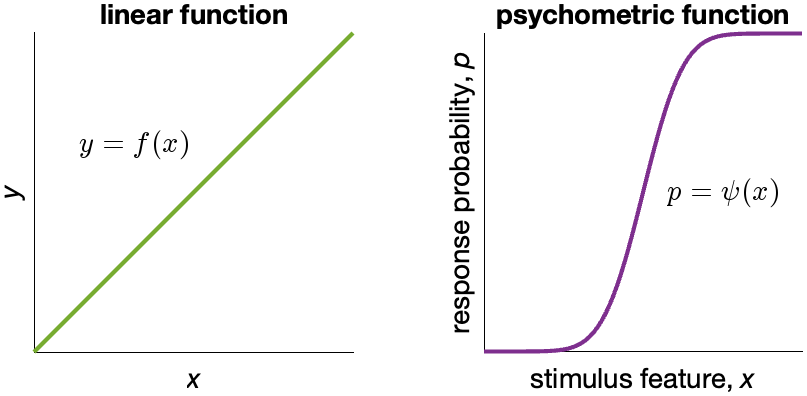

#### **How do you use a psychometric function?**

In an experiment, you repeatedly show an observer stimuli for each of your stimulus conditions (e.g., each of your chosen contrast levels). You record the observer's behavioral responses, and per condition, you calculate the probability of each possible response (e.g., at 0.4% contrast, probability detected = 0.75 & probability not detected = 0.25). You then fit a psychometric function to your data.

The fitted function most likely won't match the data exactly because of the variability of the observer's perception and their motor responses (e.g., they may click "yes" when they meant to click "no"), but a well-fit function will allow you to accurately summarize the entire curve with one number: a number you ***infer*** from the ***inferential model*** you've fit to your data. Psychometric functions thereby allow you to make your experiment more complex (e.g., by varying more than one stimulus feature) without making your data notably more difficult to interpret.

### Step 1. Create an example psychometric function

In Lab 3, we used the psychometric equation

$$
\mathbf{p}=\psi \left(\mathbf{x};\mu ,\sigma ,\gamma ,\lambda \right)=\textrm{CDF}\left(\mathbf{x};\mu ,\sigma \right)\cdot \left(1-\gamma -\lambda \right)+\gamma
$$

where $\psi$ is the psychometric function, $\mathbf{x}$ is the set of stimulus levels (the input of function $\psi$), $\mathbf{p}$ is the set of response probabilities (the output of function $\psi$), $\mu$ is the mean of the underlying cumulative density function (CDF), $\sigma$ is the standard deviation of that CDF, $\gamma$ is the guess rate, and $\lambda$ is the lapse rate.

<style>
img[alt="psychometric_params"] {
  width: 500px;
  display: block;
  margin: 0 auto;
 }
</style>

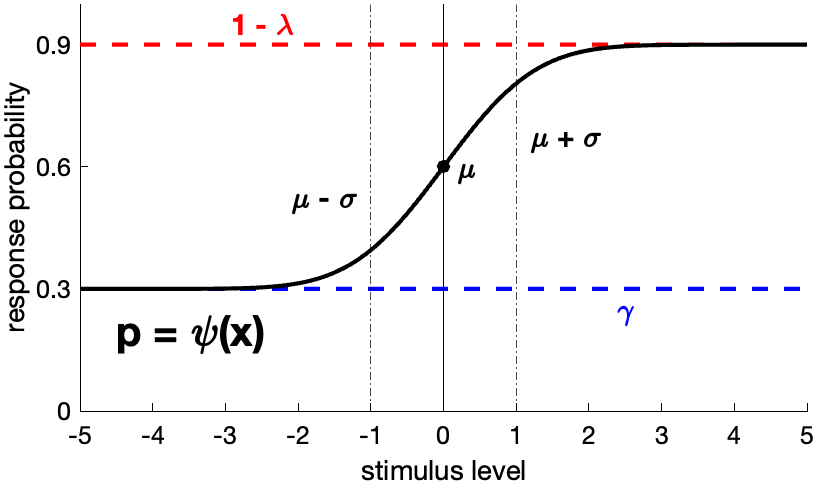

#### Define a function for a 2AFC task

Think back to the 2AFC task from Lab 3. Sinusoidal gratings of different contrast levels were shown on either the left or right side of the screen, and you had to choose between left and right, even if you didn't see a stimulus. Because you had two alternatives, you had a 50% chance of being correct just by guessing.

Let's make an example curve for that task and see what it looks like.


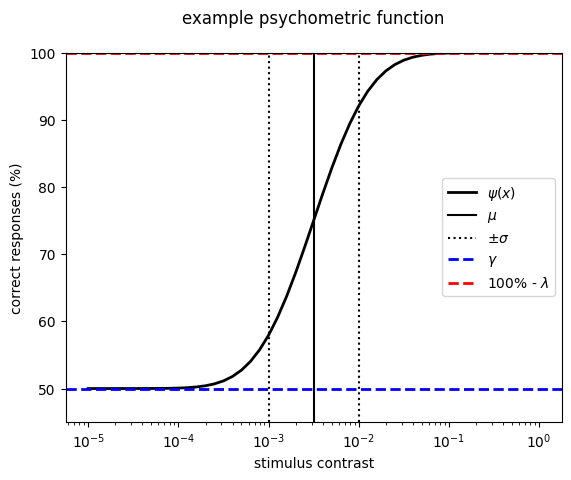

In [33]:
from pathlib import Path
from statistics import NormalDist
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.optimize import least_squares
except ImportError:
    least_squares = None

# define psychometric function
def normcdf(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.cdf, otypes=[float])(x)


def norminv(p, mu, sigma):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, np.finfo(float).eps, 1 - np.finfo(float).eps)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.inv_cdf, otypes=[float])(p)


def psyfxn(c, x):
    c = np.asarray(c, dtype=float)
    return (normcdf(x, c[0], c[1]) * (1 - c[2] - c[3])) + c[2]
# c[0] = mu
# c[1] = sigma
# c[2] = guess rate
# c[3] = lapse rate


def fit_psychometric_lsq(x, y, c0, lower_bounds, upper_bounds):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    c0 = np.asarray(c0, dtype=float)
    lower_bounds = np.asarray(lower_bounds, dtype=float)
    upper_bounds = np.asarray(upper_bounds, dtype=float)

    fixed = np.isclose(lower_bounds, upper_bounds)
    free = ~fixed

    def expand_params(free_params):
        params = c0.copy()
        params[fixed] = lower_bounds[fixed]
        params[free] = free_params
        return params

    def residuals(free_params):
        return psyfxn(expand_params(free_params), x) - y

    if least_squares is not None:
        result = least_squares(
            residuals,
            c0[free],
            bounds=(lower_bounds[free], upper_bounds[free]),
        )
        fit = expand_params(result.x)
        return fit, np.sum(result.fun ** 2)

    free_params = c0[free].copy()
    free_lower = lower_bounds[free]
    free_upper = upper_bounds[free]
    step = np.maximum(np.abs(free_params), 1.0) * 0.5

    def objective(params):
        return np.sum(residuals(params) ** 2)

    best = objective(free_params)
    for _ in range(200):
        improved = False
        for i_param in range(len(free_params)):
            for direction in (-1, 1):
                candidate = free_params.copy()
                candidate[i_param] += direction * step[i_param]
                candidate = np.maximum(candidate, free_lower)
                candidate = np.minimum(candidate, free_upper)
                if not np.all(np.isfinite(candidate)):
                    continue
                value = objective(candidate)
                if value < best:
                    free_params = candidate
                    best = value
                    improved = True
        if not improved:
            step *= 0.5
            if np.max(step) < 1e-8:
                break

    fit = expand_params(free_params)
    return fit, best

# define example parameters
psy_ex = SimpleNamespace()
psy_ex.mu = -2.5
psy_ex.sig = 0.5
psy_ex.r_guess = 0.5
psy_ex.r_lapse = 0
psy_ex.params = np.array([psy_ex.mu, psy_ex.sig, psy_ex.r_guess, psy_ex.r_lapse], dtype=float)

# create example curve
psy_ex.curve_x = 10.0 ** np.linspace(-5, 0, 51)
psy_ex.curve_y = psyfxn(psy_ex.params, np.log10(psy_ex.curve_x))

# stash RGB values for default Python colors
# (blue, orange, gold, purple, green, sky blue, red)
rgb = np.array([
    [0, 0.447, 0.741], [0.85, 0.325, 0.098], [0.929, 0.694, 0.125],
    [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933], [0.635, 0.078, 0.184]
])

# plot example curve
fig, ax = plt.subplots()
ax.plot(psy_ex.curve_x, psy_ex.curve_y * 100, 'k', linewidth=2, label=r"$\psi(x)$")
ax.set_xscale('log')
y_min = 45
ax.set_ylim(y_min, 100)
ax.set_title("example psychometric function\n")
ax.set_xlabel("stimulus contrast")
ax.set_ylabel("correct responses (%)")

# mark parameter values
ax.axvline(10.0 ** psy_ex.mu, color='k', linestyle='-', label=r"$\mu$")
ax.axvline(10.0 ** (psy_ex.mu + psy_ex.sig), color='k', linestyle=':', label=r"$\pm\sigma$")
ax.axvline(10.0 ** (psy_ex.mu - psy_ex.sig), color='k', linestyle=':')
ax.axhline(psy_ex.r_guess * 100, color='b', linestyle='--', linewidth=2, label=r"$\gamma$")
ax.axhline((1 - psy_ex.r_lapse) * 100, color='r', linestyle='--', linewidth=2, label=r"100% - $\lambda$")
ax.legend(loc='center right')
plt.show()



This plot shows our example psychometric curve and illustrates our curve's parameters. Recall that $\mu$ and $\sigma$ control the curve's central tendency and spread (x-axis), while $\gamma$ and $\lambda$ control the curve's floor and ceiling (y-axis).

### Step 2. Create a function for a more sensitive observer

Changing $\mu$ will change the location of the curve's center along the x-axis. An observer with a lower $\mu$ would be better at detecting (i.e., more sensitive to) low contrast stimuli than the observer that the curve above represents. Hence, their overall performance on the task would be better, so let's create a curve representing a more sensitive observer by lowering $\mu$.


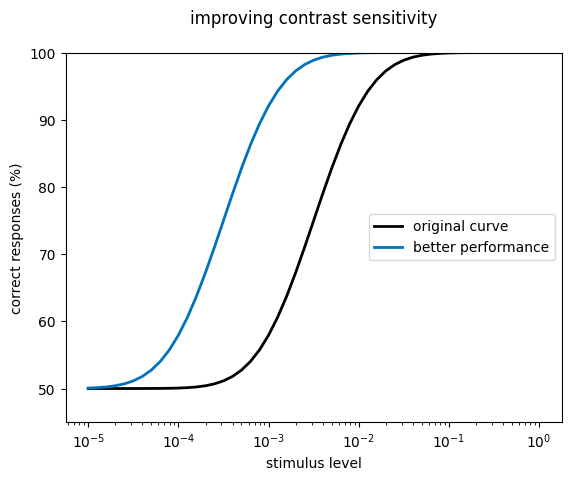

In [34]:
# build a curve with a lower mu
psy_better = SimpleNamespace()
psy_better.mu = psy_ex.mu - 1
psy_better.params = np.array([psy_better.mu, psy_ex.sig, psy_ex.r_guess, psy_ex.r_lapse], dtype=float)
psy_better.curve_y = psyfxn(psy_better.params, np.log10(psy_ex.curve_x))

# plot the original example psychometric function
fig, ax = plt.subplots()
ax.plot(psy_ex.curve_x, psy_ex.curve_y * 100, 'k', linewidth=2, label="original curve")
ax.set_xscale('log')
ax.set_ylim(45, 100)
ax.set_xlabel("stimulus level")
ax.set_ylabel("correct responses (%)")

# plot the better curve
ax.plot(psy_ex.curve_x, psy_better.curve_y * 100, linewidth=2, color=rgb[0], label="better performance")
ax.set_title("improving contrast sensitivity\n")
ax.legend(loc='center right')
plt.show()


### Step 3. Create a function for a less sensitive observer

Let's stick with changing our $\mu$ value. An observer with a lower $\mu$ would be worse at detecting (i.e., less sensitive to) low contrast stimuli than the observers that our existing curves represent, meaning their overall performance on the task would be worse. Here, let's create a curve representing a less sensitive observer by increasing $\mu$ by half as much as we decreased it.


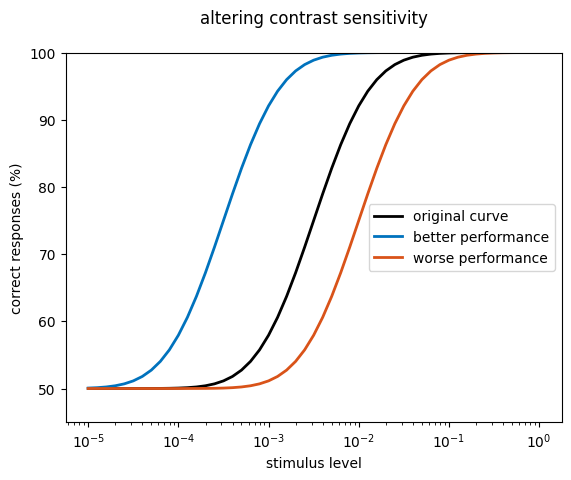

In [35]:
# build a curve with a higher mu
psy_worse = SimpleNamespace()
psy_worse.mu = psy_ex.mu + (abs(psy_ex.mu - psy_better.mu) / 2)
psy_worse.params = np.array([psy_worse.mu, psy_ex.sig, psy_ex.r_guess, psy_ex.r_lapse], dtype=float)
psy_worse.curve_y = psyfxn(psy_worse.params, np.log10(psy_ex.curve_x))

# plot the existing example psychometric functions
fig, ax = plt.subplots()
ax.plot(psy_ex.curve_x, psy_ex.curve_y * 100, 'k', linewidth=2, label="original curve")
ax.plot(psy_ex.curve_x, psy_better.curve_y * 100, linewidth=2, color=rgb[0], label="better performance")
ax.set_xscale('log')
ax.set_ylim(45, 100)
ax.set_xlabel("stimulus level")
ax.set_ylabel("correct responses (%)")

# plot the worse curve
ax.plot(psy_ex.curve_x, psy_worse.curve_y * 100, linewidth=2, color=rgb[1], label="worse performance")
ax.set_title("altering contrast sensitivity\n")
ax.legend(loc='center right')
plt.show()


Now we have three curves, each of which represents the performance of a theoretical perceptual system on a 2AFC contrast sensitivity task. We have our original example, a curve for an observer who is better at our task, and a curve for an observer who is worse at our task.

### Step 4. Confirm that overall performance would change

As you learned when simulating a signal detection experiment in Lab 2, it's always good to double check the results of your programming when building a simulation, so let's double check that the changes we made would impact overall performance on an experiment.

We wouldn't run an experiment with all of the contrast levels included in our curves, so let's first pick a more reasonable number of contrast values.


In [36]:
sim_expt = pd.DataFrame()
sim_expt["log_levels"] = np.arange(np.log10(psy_ex.curve_x[0]), np.log10(psy_ex.curve_x[-1]) + 1, 1)
sim_expt["levels"] = 10.0 ** sim_expt["log_levels"]
print(f"number of levels = {len(sim_expt['levels'])}")


number of levels = 6


Next, we need to find the response probabilities for those contrast levels.


In [37]:
sim_expt["ex"] = psyfxn(psy_ex.params, sim_expt["log_levels"])
sim_expt["better"] = psyfxn(psy_better.params, sim_expt["log_levels"])
sim_expt["worse"] = psyfxn(psy_worse.params, sim_expt["log_levels"])
display(sim_expt)


,log_levels,levels,ex,better,worse
0,-5.0,0.00001,0.500000,0.500675,0.500000
1,-4.0,0.00010,0.500675,0.579328,0.500016
2,-3.0,0.00100,0.579328,0.920672,0.511375
3,-2.0,0.01000,0.920672,0.999325,0.750000
4,-1.0,0.10000,0.999325,1.000000,0.988625
5,0.0,1.00000,1.000000,1.000000,0.999984


Finally, we can calculate the overall performance associated with each curve on this "experiment" by averaging across the probabilities per contrast level.


In [38]:
sim_prob = pd.DataFrame({
    "ex": [sim_expt["ex"].mean()],
    "better": [sim_expt["better"].mean()],
    "worse": [sim_expt["worse"].mean()],
})
display(sim_prob)


,ex,better,worse
0,0.75,0.833333,0.708333


So, **did our changes have the impact we intended?** Is the "better" probability higher than the original example ("ex")? Is the "worse" probability lower than the example?

## Part B. Making Inferences from Psychometric Functions

Recall our psychometric equation:

$$
\mathbf{p}=\psi \left(\mathbf{x};\mu ,\sigma ,\gamma ,\lambda \right)=\textrm{CDF}\left(\mathbf{x};\mu ,\sigma \right)\cdot \left(1-\gamma -\lambda \right)+\gamma
$$

When we put stimulus levels $\mathbf{x}$ into function $\psi$, we get back a set of response probabilties $\mathbf{p}$.

What if instead we want to input a response probability and find out the corresponding stimulus level? To do that, we need to ***invert*** our equation. In other words, we need to swap things around to go from our function $\mathbf{p}=\psi \left(\mathbf{x}\right)$ to its **inverse**, function $\mathbf{x}=\psi^{-1} \left(\mathbf{p}\right)$.

To isolate $\mathbf{x}$ on one side of the equation, we can first use algebra to isolate $\textrm{CDF}\left(\mathbf{x}\right)$:

$$
\mathbf{p}=\textrm{CDF}\left(\mathbf{x}\right)\cdot \left(1-\gamma -\lambda \right)+\gamma
$$

$$
\mathbf{p}-\gamma =\textrm{CDF}\left(\mathbf{x}\right)\cdot \left(1-\gamma -\lambda \right)
$$

$$
\frac{\mathbf{p}-\gamma }{1-\gamma -\lambda }=\textrm{CDF}\left(\mathbf{x}\right)
$$

We can then fully isolate $\mathbf{x}$ using the inverse of the cumulative density function (${\textrm{CDF}}^{-1}$):

$$
{\textrm{CDF}}^{-1} \left(\textrm{CDF}\left(\mathbf{x}\right)\right)={\textrm{CDF}}^{-1} \left(\frac{\mathbf{p}-\gamma }{1-\gamma -\lambda }\right)
$$

$$
\mathbf{x}={\textrm{CDF}}^{-1} \left(\frac{\mathbf{p}-\gamma }{1-\gamma -\lambda }\right)
$$

With the parameters of each function included (noted after a semicolon), this gives us the inverse psychometric equation

$$
\mathbf{x}=\psi^{-1} \left(\mathbf{p};\mu ,\sigma ,\gamma ,\lambda \right)={\textrm{CDF}}^{-1} \left(\frac{\mathbf{p}-\gamma }{1-\gamma -\lambda };\mu ,\sigma \right)
$$

Now we have the ability to put a set of response probabilties $\mathbf{p}$ into inverse function $\psi^{-1}$ and get back stimulus levels $\mathbf{x}$.

### Step 1. Use the inverse psychometric function

Let's give that a try with the original example psychometric function we created above. We'll pick several different response probabilities, put them into the inverse of our example function, and see what stimulus levels we get back.


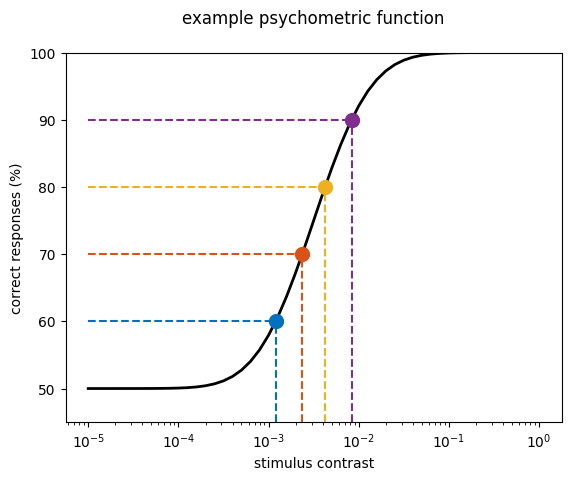

,p,log(x)
0,0.6,-2.920811
1,0.7,-2.626674
2,0.8,-2.373326
3,0.9,-2.079189


In [39]:
# define inverse psychometric function
def ipsyfxn(c, p):
    c = np.asarray(c, dtype=float)
    p = np.asarray(p, dtype=float)
    return norminv((p - c[2]) / (1 - c[2] - c[3]), c[0], c[1])
# c[0] = mu
# c[1] = sigma
# c[2] = guess rate
# c[3] = lapse rate

# use response values to find stimulus values
psy_ex.y_vals = np.arange(0.6, 0.91, 0.1)
psy_ex.log_x_vals = ipsyfxn(psy_ex.params, psy_ex.y_vals)
psy_ex.x_vals = 10.0 ** psy_ex.log_x_vals

# plot example curve
fig, ax = plt.subplots()
ax.plot(psy_ex.curve_x, psy_ex.curve_y * 100, 'k', linewidth=2)
ax.set_xscale('log')
ax.set_ylim(y_min, 100)
ax.set_title("example psychometric function\n")
ax.set_xlabel("stimulus contrast")
ax.set_ylabel("correct responses (%)")

# mark calculated values
for i_val, (this_x, this_y) in enumerate(zip(psy_ex.x_vals, psy_ex.y_vals * 100)):
    ax.plot([psy_ex.curve_x[0], this_x], [this_y, this_y], '--', color=rgb[i_val])
    ax.plot([this_x, this_x], [y_min, this_y], '--', color=rgb[i_val])
    ax.plot(this_x, this_y, '.', color=rgb[i_val], markersize=20)
plt.show()

display(pd.DataFrame({"p": psy_ex.y_vals, "log(x)": psy_ex.log_x_vals}))


**What do you think?** Does it look like our inverse function returned the right stimulus levels?

### Step 2. Measure threshold

Experimenters are often interested in measuring more than one psychometric function, so they try to find ways of summarizing each function with a single number. One common strategy for summarizing psychometric functions is finding the **threshold**.

**What is a threshold?** In psychophysics, a threshold is the stimulus level that forms a ***boundary*** between when the participant can and cannot do the task. That boundary may be clear in some circumstances, but perceptual performance tends to vary ***continuously*** across an experiment's stimulus levels (hence, the typical S-shape of psychometric curves). In other words, there may be a boundary ***line***, but usually, there's more of a boundary ***zone***. Because boundary ***zones*** are more common, the point of finding thresholds is less about the exact numbers you find and more about how the numbers you find ***compare*** to one another.

**How do you calculate threshold?** Typically, an experimenter finds a threshold value by choosing a specific response probability and calculating the stimulus level associated with that response probabiliy. Choosing a response probability is usually a somewhat arbitrary decision, but a common choice is 0.75 (75%).

#### Find the threshold of an example curve

Let's start by finding the threshold value of our original example psychometric function.


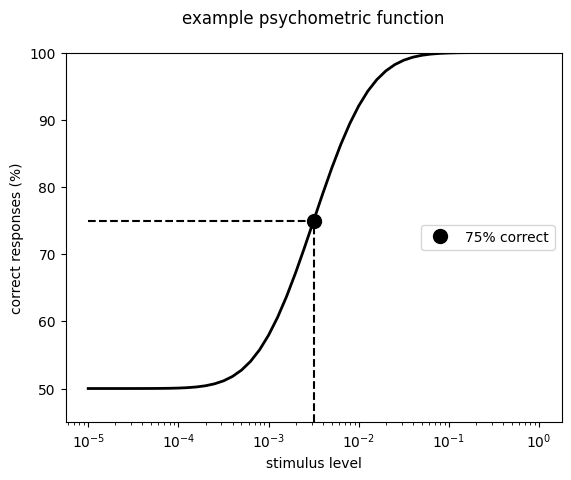

In [40]:
# compute the 75% mark for this psychometric curve
thresh_perc = 75
thresh_prob = thresh_perc / 100
psy_ex.threshold = float(10.0 ** ipsyfxn(psy_ex.params, thresh_prob))

# plot the example psychometric function
fig, ax = plt.subplots()
ax.plot(psy_ex.curve_x, psy_ex.curve_y * 100, 'k', linewidth=2)
ax.set_xscale('log')
ax.set_ylim(45, 100)
ax.set_title("example psychometric function\n")
ax.set_xlabel("stimulus level")
ax.set_ylabel("correct responses (%)")

# add the 75% mark
ax.plot([psy_ex.curve_x[0], psy_ex.threshold], [thresh_perc, thresh_perc], 'k--')
ax.plot([psy_ex.threshold, psy_ex.threshold], [45, thresh_perc], 'k--')
ax.plot(psy_ex.threshold, thresh_perc, 'k.', markersize=20, label=f"{thresh_perc}% correct")
ax.legend(loc='center right')
plt.show()


For our example curve, the 75% threshold is


In [41]:
print(f"10^{np.log10(psy_ex.threshold):g}")


10^-2.5


#### Find the threshold of a "better" curve

What about our curve with improved task performance? An observer with a lower $\mu$ would be **better** at detecting low contrast stimuli, so will lowering $\mu$ <u>**increase**</u> or <u>**decrease**</u> the threshold value?


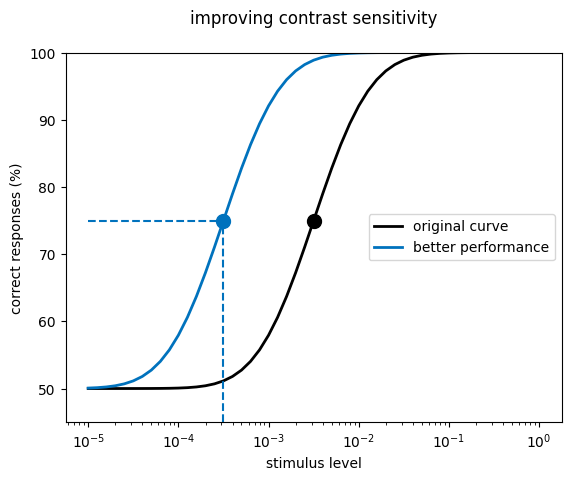

In [42]:
# compute the 75% mark for better psychometric curve
psy_better.threshold = float(10.0 ** ipsyfxn(psy_better.params, thresh_prob))

# plot the original example psychometric function
fig, ax = plt.subplots()
ax.plot(psy_ex.curve_x, psy_ex.curve_y * 100, 'k', linewidth=2, label="original curve")
ax.plot(psy_ex.threshold, thresh_perc, 'k.', markersize=20)
ax.set_xscale('log')
ax.set_ylim(45, 100)
ax.set_xlabel("stimulus level")
ax.set_ylabel("correct responses (%)")

# plot the better curve
ax.plot(psy_ex.curve_x, psy_better.curve_y * 100, linewidth=2, color=rgb[0], label="better performance")
ax.plot([psy_ex.curve_x[0], psy_better.threshold], [thresh_perc, thresh_perc], '--', color=rgb[0])
ax.plot([psy_better.threshold, psy_better.threshold], [45, thresh_perc], '--', color=rgb[0])
ax.plot(psy_better.threshold, thresh_perc, '.', markersize=20, color=rgb[0])
ax.set_title("improving contrast sensitivity\n")
ax.legend(loc='center right')
plt.show()


For our "better" curve, the 75% threshold is


In [43]:
print(f"10^{np.log10(psy_better.threshold):g}")


10^-3.5


#### Find the threshold of a "worse" curve

Finally, what about our curve with the worst task performance? An observer with a higher $\mu$ would be **worse** at detecting low contrast stimuli, so will raising $\mu$ <u>**increase**</u> or <u>**decrease**</u> the threshold value?


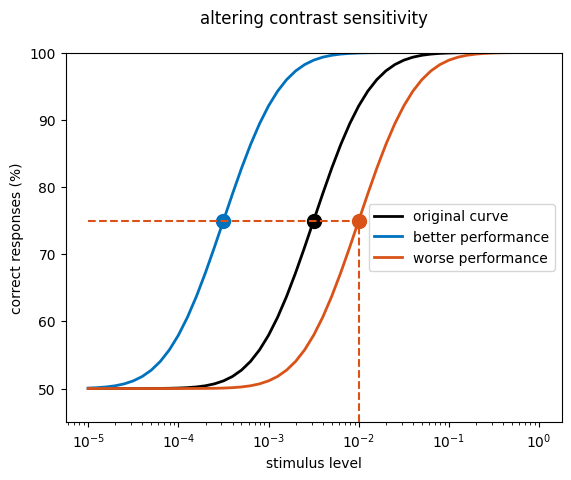

In [44]:
# compute the 75% mark for worse psychometric curve
psy_worse.threshold = float(10.0 ** ipsyfxn(psy_worse.params, thresh_prob))

# plot the original example psychometric function
fig, ax = plt.subplots()
ax.plot(psy_ex.curve_x, psy_ex.curve_y * 100, 'k', linewidth=2, label="original curve")
ax.plot(psy_ex.threshold, thresh_perc, 'k.', markersize=20)
ax.set_xscale('log')
ax.set_ylim(45, 100)
ax.set_xlabel("stimulus level")
ax.set_ylabel("correct responses (%)")

# add the better curve
ax.plot(psy_ex.curve_x, psy_better.curve_y * 100, linewidth=2, color=rgb[0], label="better performance")
ax.plot(psy_better.threshold, thresh_perc, '.', markersize=20, color=rgb[0])

# add the worse curve
ax.plot(psy_ex.curve_x, psy_worse.curve_y * 100, linewidth=2, color=rgb[1], label="worse performance")
ax.plot([psy_ex.curve_x[0], psy_worse.threshold], [thresh_perc, thresh_perc], '--', color=rgb[1])
ax.plot([psy_worse.threshold, psy_worse.threshold], [45, thresh_perc], '--', color=rgb[1])
ax.plot(psy_worse.threshold, thresh_perc, '.', markersize=20, color=rgb[1])
ax.set_title("altering contrast sensitivity\n")
ax.legend(loc='center right')
plt.show()


For our "worse" curve, the 75% threshold is


In [45]:
print(f"10^{np.log10(psy_worse.threshold):g}")


10^-2


#### Compare threshold values

So, what's the relationship between performance and threshold value?


In [46]:
threshold_table = pd.DataFrame(
    [[np.log10(psy_ex.threshold), np.log10(psy_better.threshold), np.log10(psy_worse.threshold)]],
    columns=["ex", "better", "worse"],
    index=["log(threshold)"]
)
display(threshold_table)


,ex,better,worse
log(threshold),-2.5,-3.5,-2.0


These results should show that a **"better"** observer will have a <u>**lower**</u> threshold value and a **"worse"** observer will have a <u>**higher**</u> threshold value.

We usually associate higher values with better performance, so this may seem counterintuitive unless you step through the logic. If you could only see a few of the gratings in Lab 3's 2AFC task, your threshold would fall among the <u>**highest**</u> contrast levels displayed. If you could see almost all of the gratings, your threshold would fall among the <u>**lowest**</u> contrast levels displayed. Thus, when performance on the task is **worse**, thresholds will be <u>**larger**</u>, and when performance on the task is **better**, thresholds will be <u>**smaller**</u>.

Imagine varying a second stimulus feature like spatial frequency. Thresholds will be <u>**small**</u> for spatial frequencies you can see easily, and thresholds will be <u>**large**</u> for spatial frequencies you have trouble seeing. If you plot spatial frequency on the x-axis and threshold on the y-axis, <u>**higher**</u> y-values will indicate **worse** performance. Because higher y-values usually indicate better performance, a glance at the plot will generally give the wrong impression. As a result, psychophysicists usually plot **sensitivity** instead of (or in addition to) threshold.

### Step 3. Measure sensitivity

**What is sensitivity?** Sensitivity quantifies how easily you can sense a stimulus. If you could only see a few of the gratings in Lab 3's 2AFC task, your contrast sensitivity would be <u>**low**</u>. If you could see almost all of the gratings, your contrast sensitivity would be <u>**high**</u>.

**How do you calculate sensitivity?** Thresholds are often converted into sensitivities by simply taking the reciprocal of the threshold:

$$
\textrm{sensitivity}=\frac{1}{\textrm{threshold}}
$$

#### Find the sensitivity of demo psychometric curve

The sensitivity of our original example curve is


In [47]:
psy_ex.sensitivity = 1 / psy_ex.threshold
print(f"{psy_ex.sensitivity:.2f}")


316.23


#### Find the sensitivity of a "better" curve

Meanwhile, the sensitivity of our curve with improved task performance is


In [48]:
psy_better.sensitivity = 1 / psy_better.threshold
print(f"{psy_better.sensitivity:.2f}")


3162.28


#### Find the sensitivity of a "worse" curve

Finally, the sensitivity of our curve with the worst task performance is


In [49]:
psy_worse.sensitivity = 1 / psy_worse.threshold
print(f"{psy_worse.sensitivity:.2f}")


100.00


#### Compare sensitivity values

So, what's the relationship between performance and sensitivity?


In [50]:
sensitivity_table = pd.DataFrame(
    [[psy_ex.sensitivity, psy_better.sensitivity, psy_worse.sensitivity]],
    columns=["ex", "better", "worse"],
    index=["sensitivity"]
)
display(sensitivity_table)


,ex,better,worse
sensitivity,316.227766,3162.27766,100.0


These results should show that a **"better"** observer will have a <u>**higher**</u> sensitivity value and a **"worse"** observer will have a <u>**lower**</u> sensitivity value.

Again, imagine varying a second stimulus feature like spatial frequency. Sensitivity will be <u>**high**</u> for spatial frequencies you can see easily, and sensitivity will be <u>**low**</u> for spatial frequencies you have trouble seeing. In a resulting plot with spatial frequency on the x-axis and sensitivity on the y-axis, <u>**higher**</u> y-values will indicate **better** performance, as one would generally expect. As a result, that plot should be more easy to interpret, even with only a glance.

## Part C. Measure a contrast sensitivity function

### Step 1. Data collection

To collect data, open the PsychoPy ".psyexp" file in the folder titled "contrast-sensitivity", and run that experiment. The instructions will appear on the screen before the trials begin. A single run of the experiment includes 420 trials.

<u>**IMPORTANT:**</u> To get reasonable results, you need to run the experiment multiple times. Make sure you enter a custom participant ID and use the same ID for each run. (You can leave the session number, as we aren't using it.) Each run includes 12 trials per condition, so to have at least 30 trials per condition, you need <u>**a minimum of 3 runs**</u>. You may want to run more to improve your data quality (e.g., 5 runs will get you 60 trials per condition).

### Step 2. Load your data

#### Find files for specific participant ID

Before running this section of code, enter the participant ID you used below.


In [51]:
participant_id = "demo"

# check current working directory
data_dir = Path("contrast-sensitivity") / "data"
if not data_dir.exists():
    raise FileNotFoundError(
        "PsychoPy data folder not found. Try changing your current Python "
        "folder to the folder containing this notebook."
    )

# find csv files
file_paths = sorted(data_dir.glob(f"{participant_id}*.csv"))
file_paths = [path for path in file_paths if path.name.startswith(participant_id)]

file_info = pd.DataFrame({
    "name": [path.name for path in file_paths],
    "folder": [str(path.parent) for path in file_paths],
    "path": file_paths,
})

# make sure files were found
n_files = len(file_info)
if n_files == 0:
    raise FileNotFoundError("No files found.")
else:
    print("data files found:")
    for name in file_info["name"]:
        print(f'    "{name}"')


data files found:
    "demo_contrast_sensitivity_2025-02-03_13h44.20.629.csv"
    "demo_contrast_sensitivity_2025-02-03_13h56.33.003.csv"
    "demo_contrast_sensitivity_2025-02-03_14h11.15.662.csv"
    "demo_contrast_sensitivity_2025-02-03_14h23.25.595.csv"
    "demo_contrast_sensitivity_2025-02-03_14h39.59.865.csv"
    "demo_contrast_sensitivity_2025-02-03_14h57.04.486.csv"


**Confirm that all of your data files are listed above.** There should be one file for each of your experiment runs (i.e., at least 3 files).

#### Load and merge data tables


In [52]:
# load data and stack it into one table
expt_data = pd.concat(
    [pd.read_csv(path).iloc[1:].reset_index(drop=True) for path in file_info["path"]],
    ignore_index=True
)

# remove columns associated with the instructions in PsychoPy
remove = ["notes", "begin_experiment.started", "begin_experiment.stopped"]
expt_data = expt_data.drop(columns=remove, errors="ignore")

# display data table size
n_trials = len(expt_data)
print(f"number of trials = {n_trials}")


number of trials = 2400


### Step 3. Analyze your data

For this experiment, the stimulus was a sinusoidal grating with a Gaussian mask. Both the contrast and spatial frequency (SF) of the grating varied. As a reminder, a grating with a contrast of 0 would have the same luminance as the background (middle gray), and a grating with a contrast of 1 would have luminance values ranging from black to white (the full possible range).

For each trial, PsychoPy saved the stimulus's contrast, number of cycles, and location (1 = right; -1 = left) as well as the participant's response. The responses were stored as 'left' or 'right'.


In [53]:
# stash the stimulus location and response data
stim_location = expt_data["location"].astype(float).to_numpy()
resp_key = expt_data["response.keys"].astype(str)

# convert the response key to 1 for right and -1 for left
# (to match stimulus location)
resp_location = np.where(resp_key.eq("right"), 1, -1)


#### Calculate spatial frequency

While PsychoPy stores the number of cycles in each stimulus grating, we need to calculate their (approximate) spatial frequency. Spatial frequency is often expressed in **cycles per degree** (cpd). In this context, degree means **degree of visual angle**. We already know the number of cycles per stimulus, so to calculate cycles per degree, we just need to find their size in degrees of visual angle.

This will require that we convert from centimeters to degrees. The schematic below shows how we can use measurements of viewing distance and screen height (or width) to calculate that conversion factor (equations below the "participant").

<style>
img[alt="psychophysics_degrees"] {
  width: 500px;
  display: block;
  margin: 0 auto;
 }
</style>

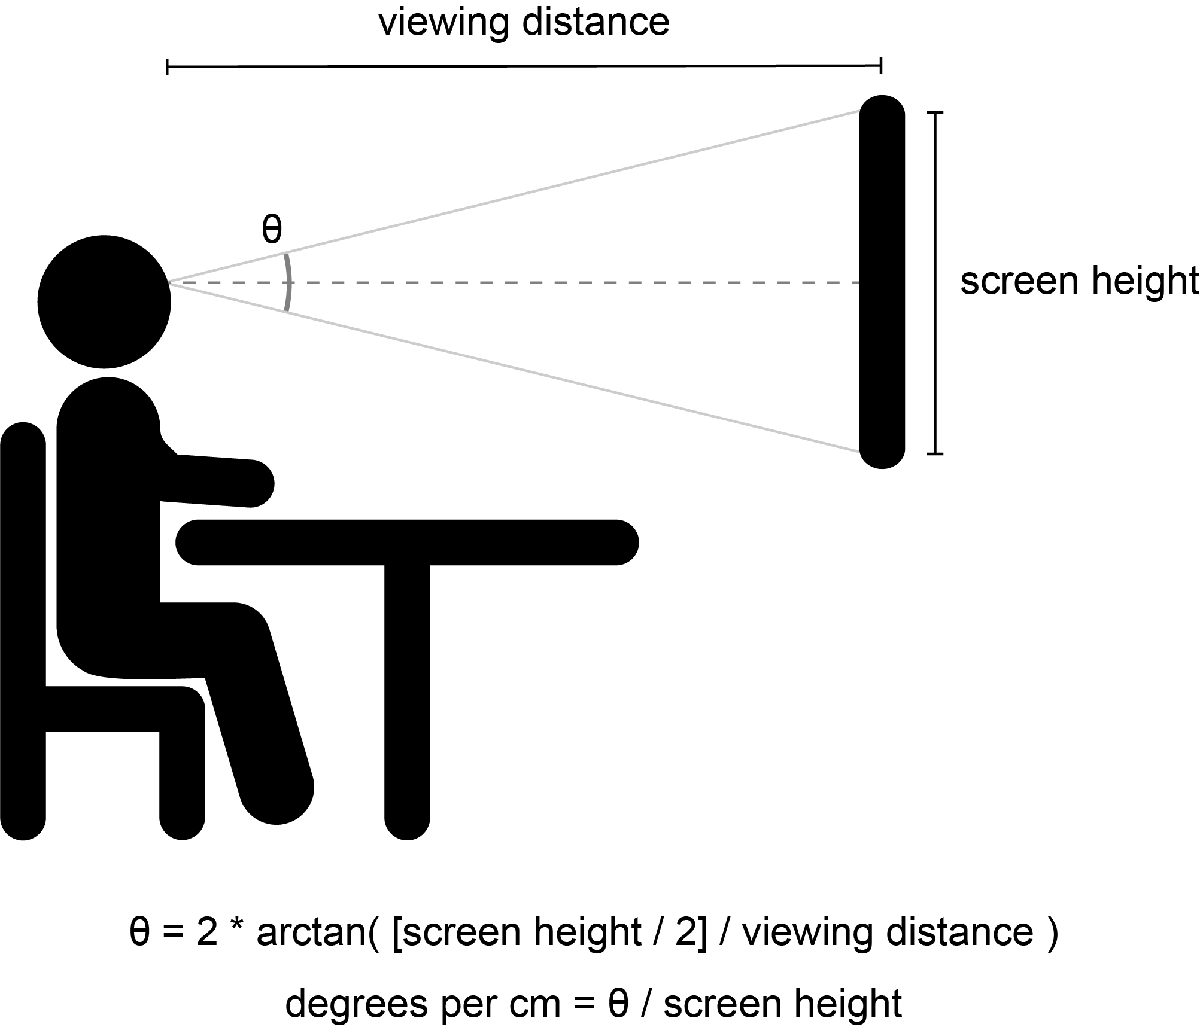

The code below includes rough viewing distance and screen height measurements that should be approximately accurate, but you can replace those numbers with your own if you'd like to be more precise.


In [54]:
# define measurements
# (60 cm distance and 20 cm height should be about right)
viewing_dist_cm = 60
screen_height_cm = 20

# calculate cm/deg conversion factor
screen_height_deg = 2 * np.degrees(np.arctan2(screen_height_cm / 2, viewing_dist_cm))
degrees_per_cm = screen_height_deg / screen_height_cm

# store size parameter used in PsychoPy
# (units = fraction of screen height)
size_fraction = 0.2  # 20% of screen's pixel height

# convert stimulus size to cm & to degrees
size_cm = size_fraction * screen_height_cm  # fraction to cm
size_degrees = size_cm * degrees_per_cm  # cm to deg

# calculate spatial frequency for all stimuli
stim_sf = expt_data["n_cycles"].astype(float).to_numpy() / size_degrees

# display spatial frequency levels
print("spatial frequencies:")
print(np.unique(stim_sf))


spatial frequencies:
[0.26420576 0.52841151 1.05682303 2.11364605 4.22729211]


*Keep in mind:* For these number to be "exact", your head would need to be in a stable position at a fixed viewing distance for the entirety of the experiment (e.g., via a chin rest and forehead bar). Since that was not the case, these spatial frequency numbers are fairly approximate.

#### Determine whether responses were correct or incorrect

For a responses to be correct, the location of the stimulus and the location that the participant reported must match (i.e., both 'left' or both 'right').


In [55]:
# determine whether responses were correct or incorrect
resp_correct = stim_location == resp_location

# display overall performance
print(f"overall percentage correct = {np.mean(resp_correct) * 100:.2f}%")


overall percentage correct = 77.79%


Your overall percentage correct is displayed above as a ***rough*** **sanity check**.

If you're performing below change (50% for this task), that's a sign something may have gone wrong with the experiment or analysis. (Perhaps your screen wasn't displaying the stimuli as intended, or perhaps a software malfunction caused your responses to be logged incorrectly.)

Performance at or near perfect could also be a sign of a problem, as psychophysical experiments generally aim to test the ***limits*** of perception. We can learn ***much*** more from the **sloped** part of a psychometric curve than from its floor or ceiling, so we don't want participants to do too poorly <u>or</u> too well on a task.

Generally, we want a curve to have at least one condition at its floor and one at its ceiling, so an overall performance level right in between chance and perfect (75% in this case) is a good sign.

#### Determine percentage correct per condition

For each contrast and spatial frequency, how often did you choose the correct side of the screen?


In [56]:
# average across responses per contrast level
analysis_table = pd.DataFrame({
    "response": resp_correct,
    "contrast": expt_data["contrast"].astype(float),
    "sf": stim_sf,
})
expt_results = (
    analysis_table
    .groupby(["contrast", "sf"], as_index=False)
    .agg(
        n_trials=("response", "size"),
        n_correct=("response", "sum"),
        prob_correct=("response", "mean"),
    )
)

# stash stimulus levels & counts
contrast_levels = np.sort(expt_results["contrast"].unique())
sf_levels = np.sort(expt_results["sf"].unique())

n_contrast = len(contrast_levels)
n_sf = len(sf_levels)

# group results by sf level
results_per_sf = []
for sf in sf_levels:
    results_per_sf.append(expt_results[expt_results["sf"].eq(sf)].reset_index(drop=True))

# display results
display(expt_results)



,contrast,sf,n_trials,n_correct,prob_correct
0,1.000000e-08,0.264206,72,34,0.472222
1,1.000000e-08,0.528412,72,38,0.527778
2,1.000000e-08,1.056823,72,36,0.500000
3,1.000000e-08,2.113646,72,35,0.486111
4,1.000000e-08,4.227292,72,39,0.541667
5,1.000000e-06,0.264206,48,30,0.625000
6,1.000000e-06,0.528412,48,25,0.520833
7,1.000000e-06,1.056823,48,31,0.645833
8,1.000000e-06,2.113646,48,32,0.666667
9,1.000000e-06,4.227292,48,29,0.604167


You may notice there are quite a few stimulus conditions in this experiment. To be precise:


In [57]:
print(f"{n_contrast} contrasts * {n_sf} SFs = {len(expt_results)} conditions")


8 contrasts * 5 SFs = 40 conditions


#### Plot percentage correct per stimulus condition

How can we start to make sense of all this data from all these different conditions? A plot visualizing each individual trial would probably be too crowded to be very useful, so how about instead, we plot performance as a function of contrast with a separate line for each spatial frequency?


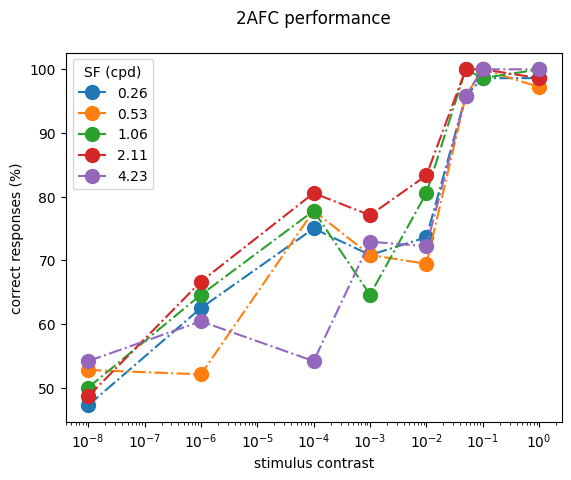

In [58]:
fig, ax = plt.subplots()
for results in results_per_sf:
    ax.plot(
        results["contrast"], results["prob_correct"] * 100,
        linestyle='-.', marker='.', markersize=20
    )
ax.set_xscale('log')
ax.set_title("2AFC performance\n")
ax.set_xlabel("stimulus contrast")
ax.set_ylabel("correct responses (%)")
lgd = ax.legend([f"{sf:.2f}" for sf in sf_levels], loc='upper left')
lgd.set_title("SF (cpd)")
plt.show()


**What do you see?** Do you notice anything interesting? How does performance change when spatial frequency increases or decreases?

### Step 4. Fit psychometric curves

By now, you've hopefully gotten a sense of how useful psychometric functions can be, particularly in an experiment with more than one independent variable (i.e., more than one variable that the experimenter manipulates). Since today's experiment has two independent variables, we better fit some curves toot suite!


In [59]:
# define parameter settings
# c[0] = mu
# c[1] = sigma
# c[2] = guess rate
# c[3] = lapse rate
c0 = np.array([0, 1, 0.5, 0], dtype=float)  # starting values
c_lower_b = np.array([-np.inf, 0, 0.5, 0], dtype=float)  # lower bounds
c_upper_b = np.array([1, np.inf, 0.5, 0], dtype=float)  # upper bounds - force rate values to be 0.5 and 0

# loop over spatial frequency levels
n_params = len(c0)
psyfit_params = np.full((n_sf, n_params), np.nan)
psyfit_resnorm = np.full(n_sf, np.nan)

for i_sf, results in enumerate(results_per_sf):
    # fit function to data
    this_fit, this_resnorm = fit_psychometric_lsq(
        np.log10(results["contrast"].to_numpy(dtype=float)),  # x values of psychometric curve
        results["prob_correct"].to_numpy(dtype=float),  # y values of psychometric curve
        c0,
        c_lower_b,
        c_upper_b,
    )
    psyfit_params[i_sf, :] = this_fit
    psyfit_resnorm[i_sf] = this_resnorm

psyfit_results = pd.DataFrame(
    np.column_stack([sf_levels, psyfit_params, psyfit_resnorm]),
    columns=["sf", "mu", "sigma", "guess_rate", "lapse_rate", "resnorm"]
)

# display results
display(psyfit_results)



,sf,mu,sigma,guess_rate,lapse_rate,resnorm
0,0.264206,-3.366001,2.494393,0.5,0.0,0.035780
1,0.528412,-3.136521,2.248856,0.5,0.0,0.049195
2,1.056823,-3.600934,2.491229,0.5,0.0,0.047870
3,2.113646,-4.236777,2.550086,0.5,0.0,0.022681
4,4.227292,-2.508527,1.229977,0.5,0.0,0.032172


**The more parameters you have, the "noisier" your fits will be.** We're trying to get away with including as few trials as possible in this experiment, which can mean our data will be more noisy (i.e., less reliable). Here, we'll match the MATLAB live script by using a least-squares fit to the averaged percentage correct values and fixing the guess and lapse rates at 0.5 and 0.

#### Create curves to plot

Let's plot your fitted curves on top of your data to visualize their goodness-of-fit (i.e., how well they represent your measured data). As usual, you'll first need a series of x-values, and you'll then need to evaluate each fitted psychometric function at those x-values to get your y-values.



In [60]:
# pick x values (evenly spaced along log axis)
log_c_levels = np.log10(contrast_levels)
psy_x = np.logspace(log_c_levels[0], log_c_levels[-1], 300)

# use psychometric curve function to calculate y values
psy_y = np.full((len(psy_x), n_sf), np.nan)
for i_sf in range(n_sf):
    psy_y[:, i_sf] = psyfxn(psyfit_params[i_sf, :], np.log10(psy_x))



#### Plot fitted psychometric curves


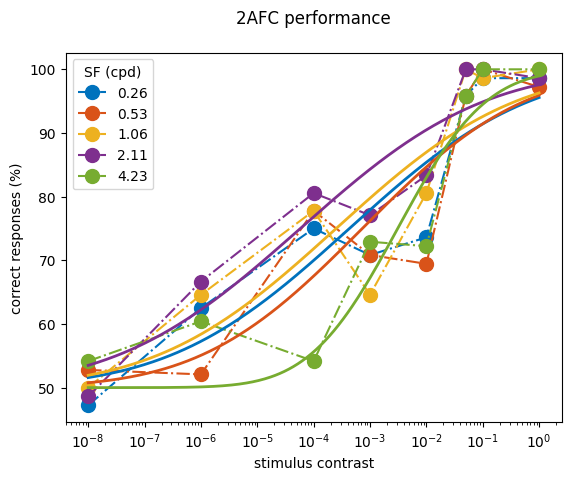

In [61]:
# plot data per spatial frequency
fig, ax = plt.subplots()
for i_sf, results in enumerate(results_per_sf):
    ax.plot(
        results["contrast"], results["prob_correct"] * 100,
        color=rgb[i_sf], linestyle='-.', marker='.', markersize=20
    )
ax.set_xscale('log')
ax.set_title("2AFC performance\n")
ax.set_xlabel("stimulus contrast")
ax.set_ylabel("correct responses (%)")

# plot fitted curve per spatial frequency
for i_sf in range(n_sf):
    ax.plot(psy_x, psy_y[:, i_sf] * 100, '-', color=rgb[i_sf], linewidth=2)
lgd = ax.legend([f"{sf:.2f}" for sf in sf_levels], loc='upper left')
lgd.set_title("SF (cpd)")
plt.show()


**What do you think?** Did the least-squares model do a good job fitting your data? Are some adjustments needed? What do you notice about how the curves change with spatial frequency?

### Step 5. Compare performance across spatial frequencies

Earlier, we covered the utility of computing a single number to represent an entire curve. Now that you're looking at multiple psychometric fits, it's hopefully even easier for you to appreciate why psychophysicists would want to extract a single number (even if some arbitrary decision-making is required along the way).

#### **Compute threshold and sensivity from psychometric curves**

We previously computed 75% threshold and sensivity. Let's repeat those calculations here for each the psychometric curves you measured.



In [62]:
# compute the 75% mark for each psychometric curve
thresh_prob = 0.75
c_threshold = np.full(n_sf, np.nan)
for i_sf in range(n_sf):
    c_threshold[i_sf] = 10.0 ** ipsyfxn(psyfit_params[i_sf, :], thresh_prob)

# compute sensitivity
c_sensitivity = 1 / c_threshold

# display results
c_results = pd.DataFrame({
    "sf": sf_levels,
    "log(threshold)": np.log10(c_threshold),
    "sensitivity": c_sensitivity,
})
display(c_results)


,sf,log(threshold),sensitivity
0,0.264206,-3.366001,2322.742757
1,0.528412,-3.136521,1369.370231
2,1.056823,-3.600934,3989.642209
3,2.113646,-4.236777,17249.510138
4,4.227292,-2.508527,322.498236


**What do you notice?** What range do each of the values have? Can you spot any trends right away? Does anything stand out or surprise you?

#### **Plot threshold and sensivity as a function of spatial frequency**


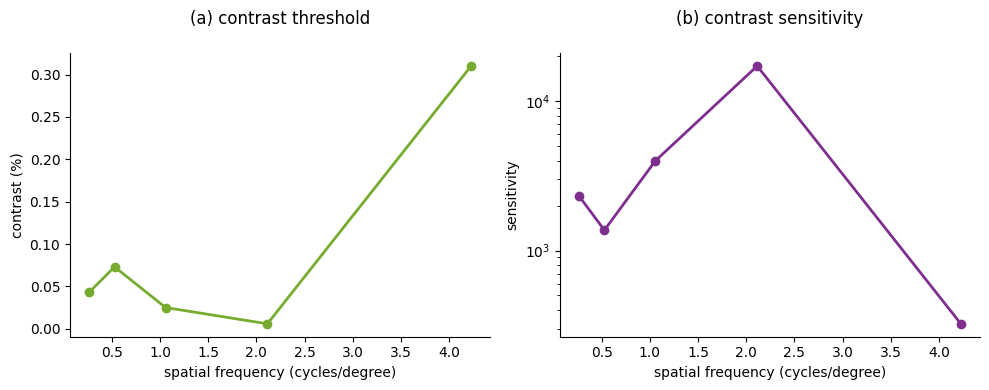

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# plot threshold values
ax1.plot(sf_levels, c_threshold * 100, '-o', linewidth=2, color=rgb[4], markerfacecolor=rgb[4])
ax1.set_title("(a) contrast threshold\n")
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_xlabel("spatial frequency (cycles/degree)")
ax1.set_ylabel("contrast (%)")

# plot sensitivity values
ax2.plot(sf_levels, c_sensitivity, '-o', linewidth=2, color=rgb[3], markerfacecolor=rgb[3])
ax2.set_yscale('log')
ax2.set_title("(b) contrast sensitivity\n")
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_xlabel("spatial frequency (cycles/degree)")
ax2.set_ylabel("sensitivity")

plt.tight_layout()
plt.show()


**What do you think?** What's similar? What's different? Which do you find easier to interpret?

**What about your contrast sensitivity function?** How does your curve compare to a typical example you might see in a textbook? Is the overall shape the same? What, if anything, is different about it?
